# Ames Housing Dataset - Exploratory Data Analysis (EDA)
**Course**: ITC6103 - Applied Machine Learning

This notebook provides a comprehensive EDA for the regression task using the Ames Housing dataset. It includes data inspection, missing value analysis, variable relationships, feature distribution, correlation analysis, and transformation insights.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [36]:
df = pd.read_csv("../data/AmesHousing.csv")
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('/', '_')

df.shape

(2930, 82)

In [37]:
df.head()

,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,1st_Flr_SF,2nd_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Yr_Blt,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS_SubClass      2930 non-null   int64  
 3   MS_Zoning        2930 non-null   object 
 4   Lot_Frontage     2440 non-null   float64
 5   Lot_Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot_Shape        2930 non-null   object 
 9   Land_Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot_Config       2930 non-null   object 
 12  Land_Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition_1      2930 non-null   object 
 15  Condition_2      2930 non-null   object 
 16  Bldg_Type        2930 non-null   object 
 17  House_Style   

In [39]:
df.describe(include='all')

,Order,PID,MS_SubClass,MS_Zoning,Lot_Frontage,Lot_Area,Street,Alley,Lot_Shape,Land_Contour,Utilities,Lot_Config,Land_Slope,Neighborhood,Condition_1,Condition_2,Bldg_Type,House_Style,Overall_Qual,Overall_Cond,Year_Built,Year_Remod_Add,Roof_Style,Roof_Matl,Exterior_1st,Exterior_2nd,Mas_Vnr_Type,Mas_Vnr_Area,Exter_Qual,Exter_Cond,Foundation,Bsmt_Qual,Bsmt_Cond,Bsmt_Exposure,BsmtFin_Type_1,BsmtFin_SF_1,BsmtFin_Type_2,BsmtFin_SF_2,Bsmt_Unf_SF,Total_Bsmt_SF,Heating,Heating_QC,Central_Air,Electrical,1st_Flr_SF,2nd_Flr_SF,Low_Qual_Fin_SF,Gr_Liv_Area,Bsmt_Full_Bath,Bsmt_Half_Bath,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,Kitchen_Qual,TotRms_AbvGrd,Functional,Fireplaces,Fireplace_Qu,Garage_Type,Garage_Yr_Blt,Garage_Finish,Garage_Cars,Garage_Area,Garage_Qual,Garage_Cond,Paved_Drive,Wood_Deck_SF,Open_Porch_SF,Enclosed_Porch,3Ssn_Porch,Screen_Porch,Pool_Area,Pool_QC,Fence,Misc_Feature,Misc_Val,Mo_Sold,Yr_Sold,Sale_Type,Sale_Condition,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2930,2440.000000,2930.000000,2930,198,2930,2930,2930,2930,2930,2930,2930,2930,2930,2930,2930.000000,2930.000000,2930.000000,2930.000000,2930,2930,2930,2930,1155,2907.000000,2930,2930,2930,2850,2850,2847,2850,2929.000000,2849,2929.000000,2929.000000,2929.000000,2930,2930,2930,2929,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930,2930.000000,2930,2930.000000,1508,2773,2771.000000,2771,2929.000000,2929.000000,2771,2771,2930,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,13,572,106,2930.000000,2930.000000,2930.000000,2930,2930,2930.000000
unique,NaN,NaN,NaN,7,NaN,NaN,2,2,4,4,3,5,3,28,9,8,5,8,NaN,NaN,NaN,NaN,6,8,16,17,4,NaN,4,5,6,5,5,4,6,NaN,6,NaN,NaN,NaN,6,5,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,8,NaN,5,6,NaN,3,NaN,NaN,5,5,3,NaN,NaN,NaN,NaN,NaN,NaN,4,4,5,NaN,NaN,NaN,10,6,NaN
top,NaN,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,NaN,NaN,NaN,NaN,Gable,CompShg,VinylSd,VinylSd,BrkFace,NaN,TA,TA,PConc,TA,TA,No,GLQ,NaN,Unf,NaN,NaN,NaN,GasA,Ex,Y,SBrkr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TA,NaN,Typ,NaN,Gd,Attchd,NaN,Unf,NaN,NaN,TA,TA,Y,NaN,NaN,NaN,NaN,NaN,NaN,Ex,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,NaN,2273,NaN,NaN,2918,120,1859,2633,2927,2140,2789,443,2522,2900,2425,1481,NaN,NaN,NaN,NaN,2321,2887,1026,1015,880,NaN,1799,2549,1310,1283,2616,1906,859,NaN,2499,NaN,NaN,NaN,2885,1495,2734,2682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1494,NaN,2728,NaN,744,1731,NaN,1231,NaN,NaN,2615,2665,2652,NaN,NaN,NaN,NaN,NaN,NaN,4,330,95,NaN,NaN,NaN,2536,2413,NaN
mean,1465.50000,7.144645e+08,57.387372,NaN,69.224590,10147.921843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.094881,5.563140,1971.356314,1984.266553,NaN,NaN,NaN,NaN,NaN,101.896801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,442.629566,NaN,49.722431,559.262547,1051.614544,NaN,NaN,NaN,NaN,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,NaN,6.443003,NaN,0.599317,NaN,NaN,1978.132443,NaN,1.766815,472.819734,NaN,NaN,NaN,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,NaN,NaN,NaN,50.635154,6.216041,2007.790444,NaN,NaN,180796.060068
std,845.96247,1.887308e+08,42.638025,NaN,23.365335,7880.017759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.411026,1.111537,30.245361,20.860286,NaN,NaN,NaN,NaN,NaN,179.112611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,455.590839,NaN,169.168476,439.494153,440.615067,NaN,NaN,NaN,NaN,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,NaN,1.572964,NaN,0.647921,NaN,NaN,25.528411,NaN,0.760566,215.046549,NaN,NaN,NaN,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,NaN,NaN,NaN,566.344288,2.714492,1.316613,NaN,NaN,79886.692357
min,1.00000,5.263011e+08,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1872.000000,1950.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,

In [40]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Pool_QC           2917
Misc_Feature      2824
Alley             2732
Fence             2358
Mas_Vnr_Type      1775
Fireplace_Qu      1422
Lot_Frontage       490
Garage_Cond        159
Garage_Qual        159
Garage_Finish      159
Garage_Yr_Blt      159
Garage_Type        157
Bsmt_Exposure       83
BsmtFin_Type_2      81
Bsmt_Cond           80
Bsmt_Qual           80
BsmtFin_Type_1      80
Mas_Vnr_Area        23
Bsmt_Half_Bath       2
Bsmt_Full_Bath       2
BsmtFin_SF_1         1
Garage_Cars          1
Garage_Area          1
Total_Bsmt_SF        1
Bsmt_Unf_SF          1
BsmtFin_SF_2         1
Electrical           1
dtype: int64

<Axes: >

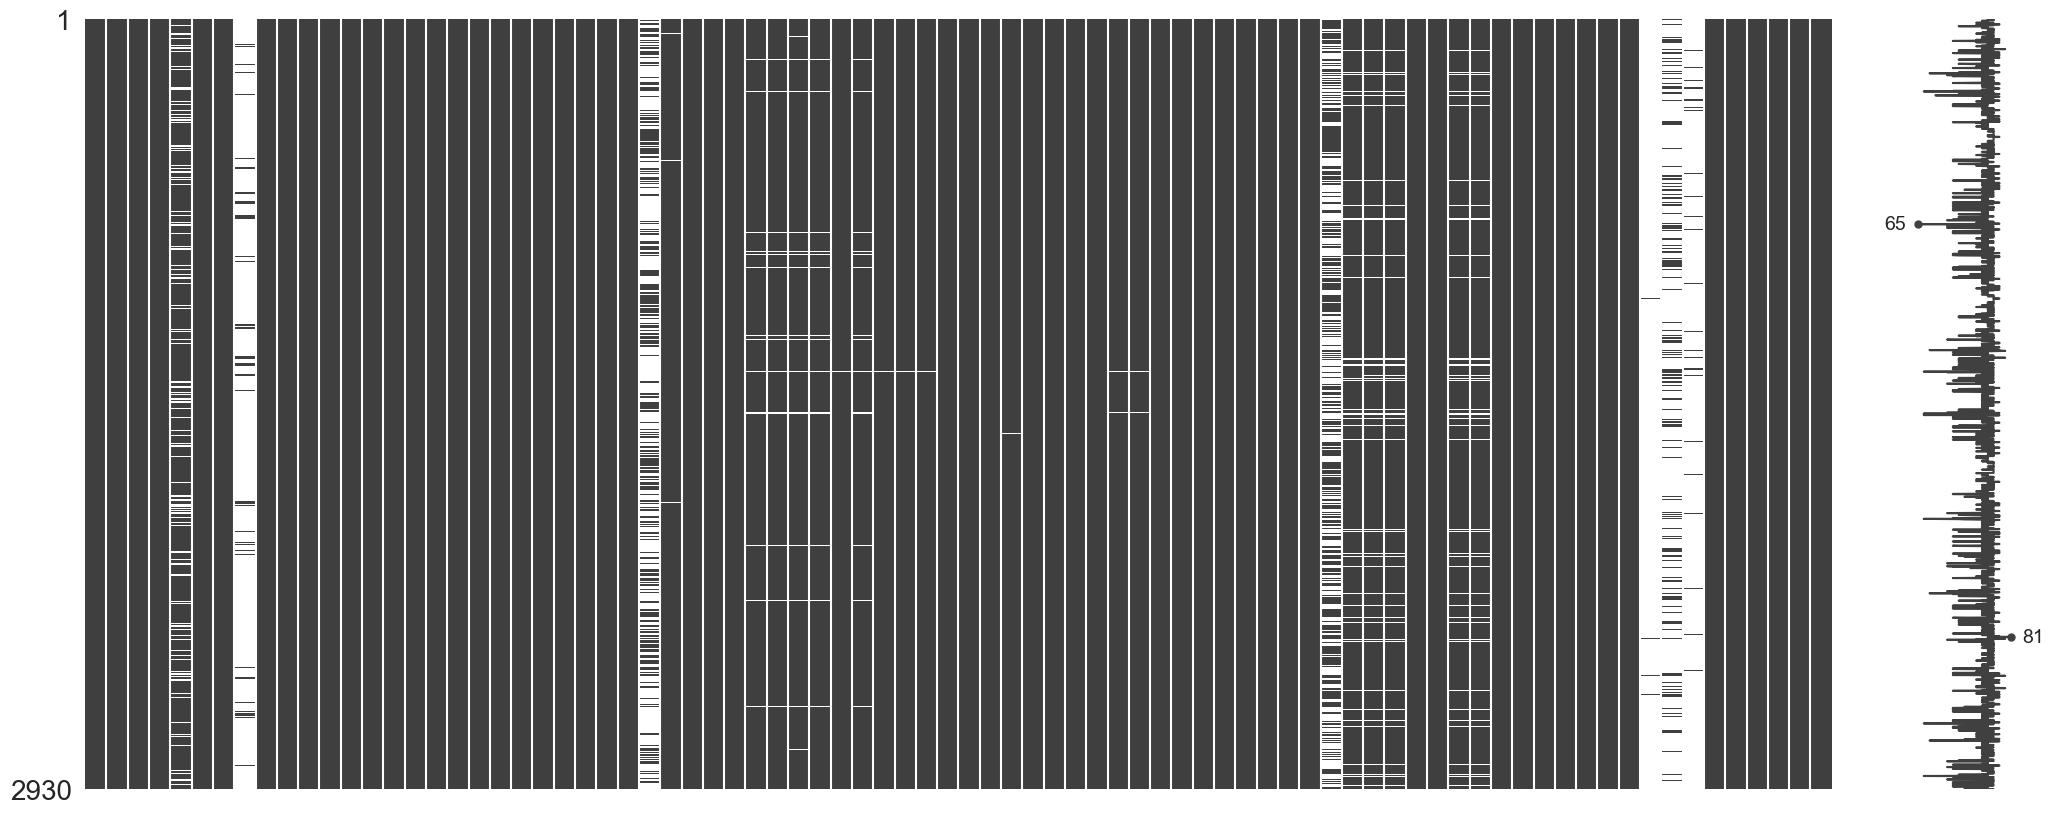

In [41]:
msno.matrix(df)

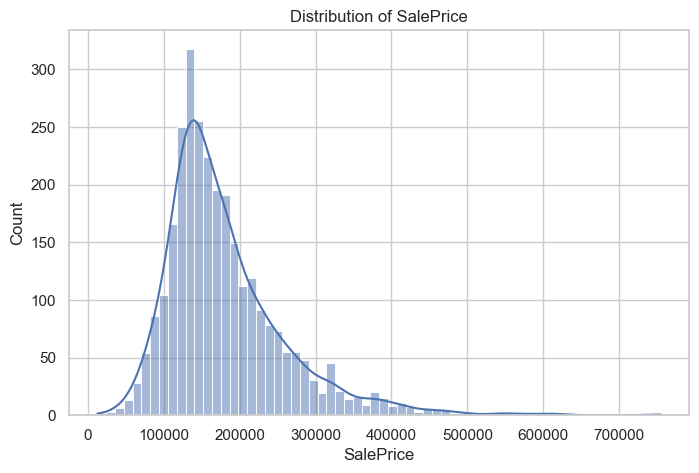

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.show()

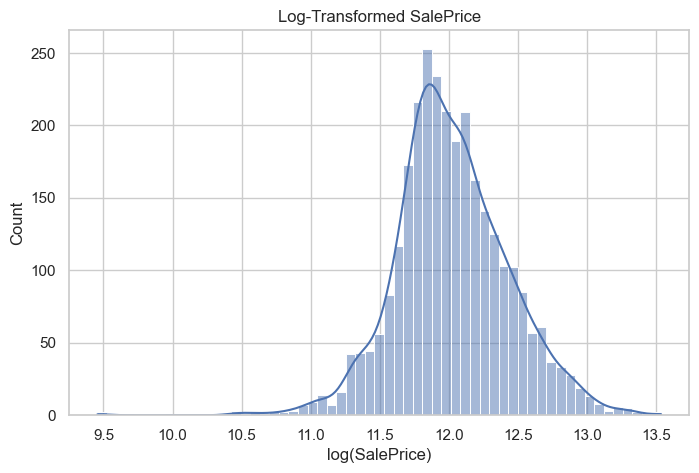

In [43]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df['SalePrice']), kde=True)
plt.title('Log-Transformed SalePrice')
plt.xlabel('log(SalePrice)')
plt.show()

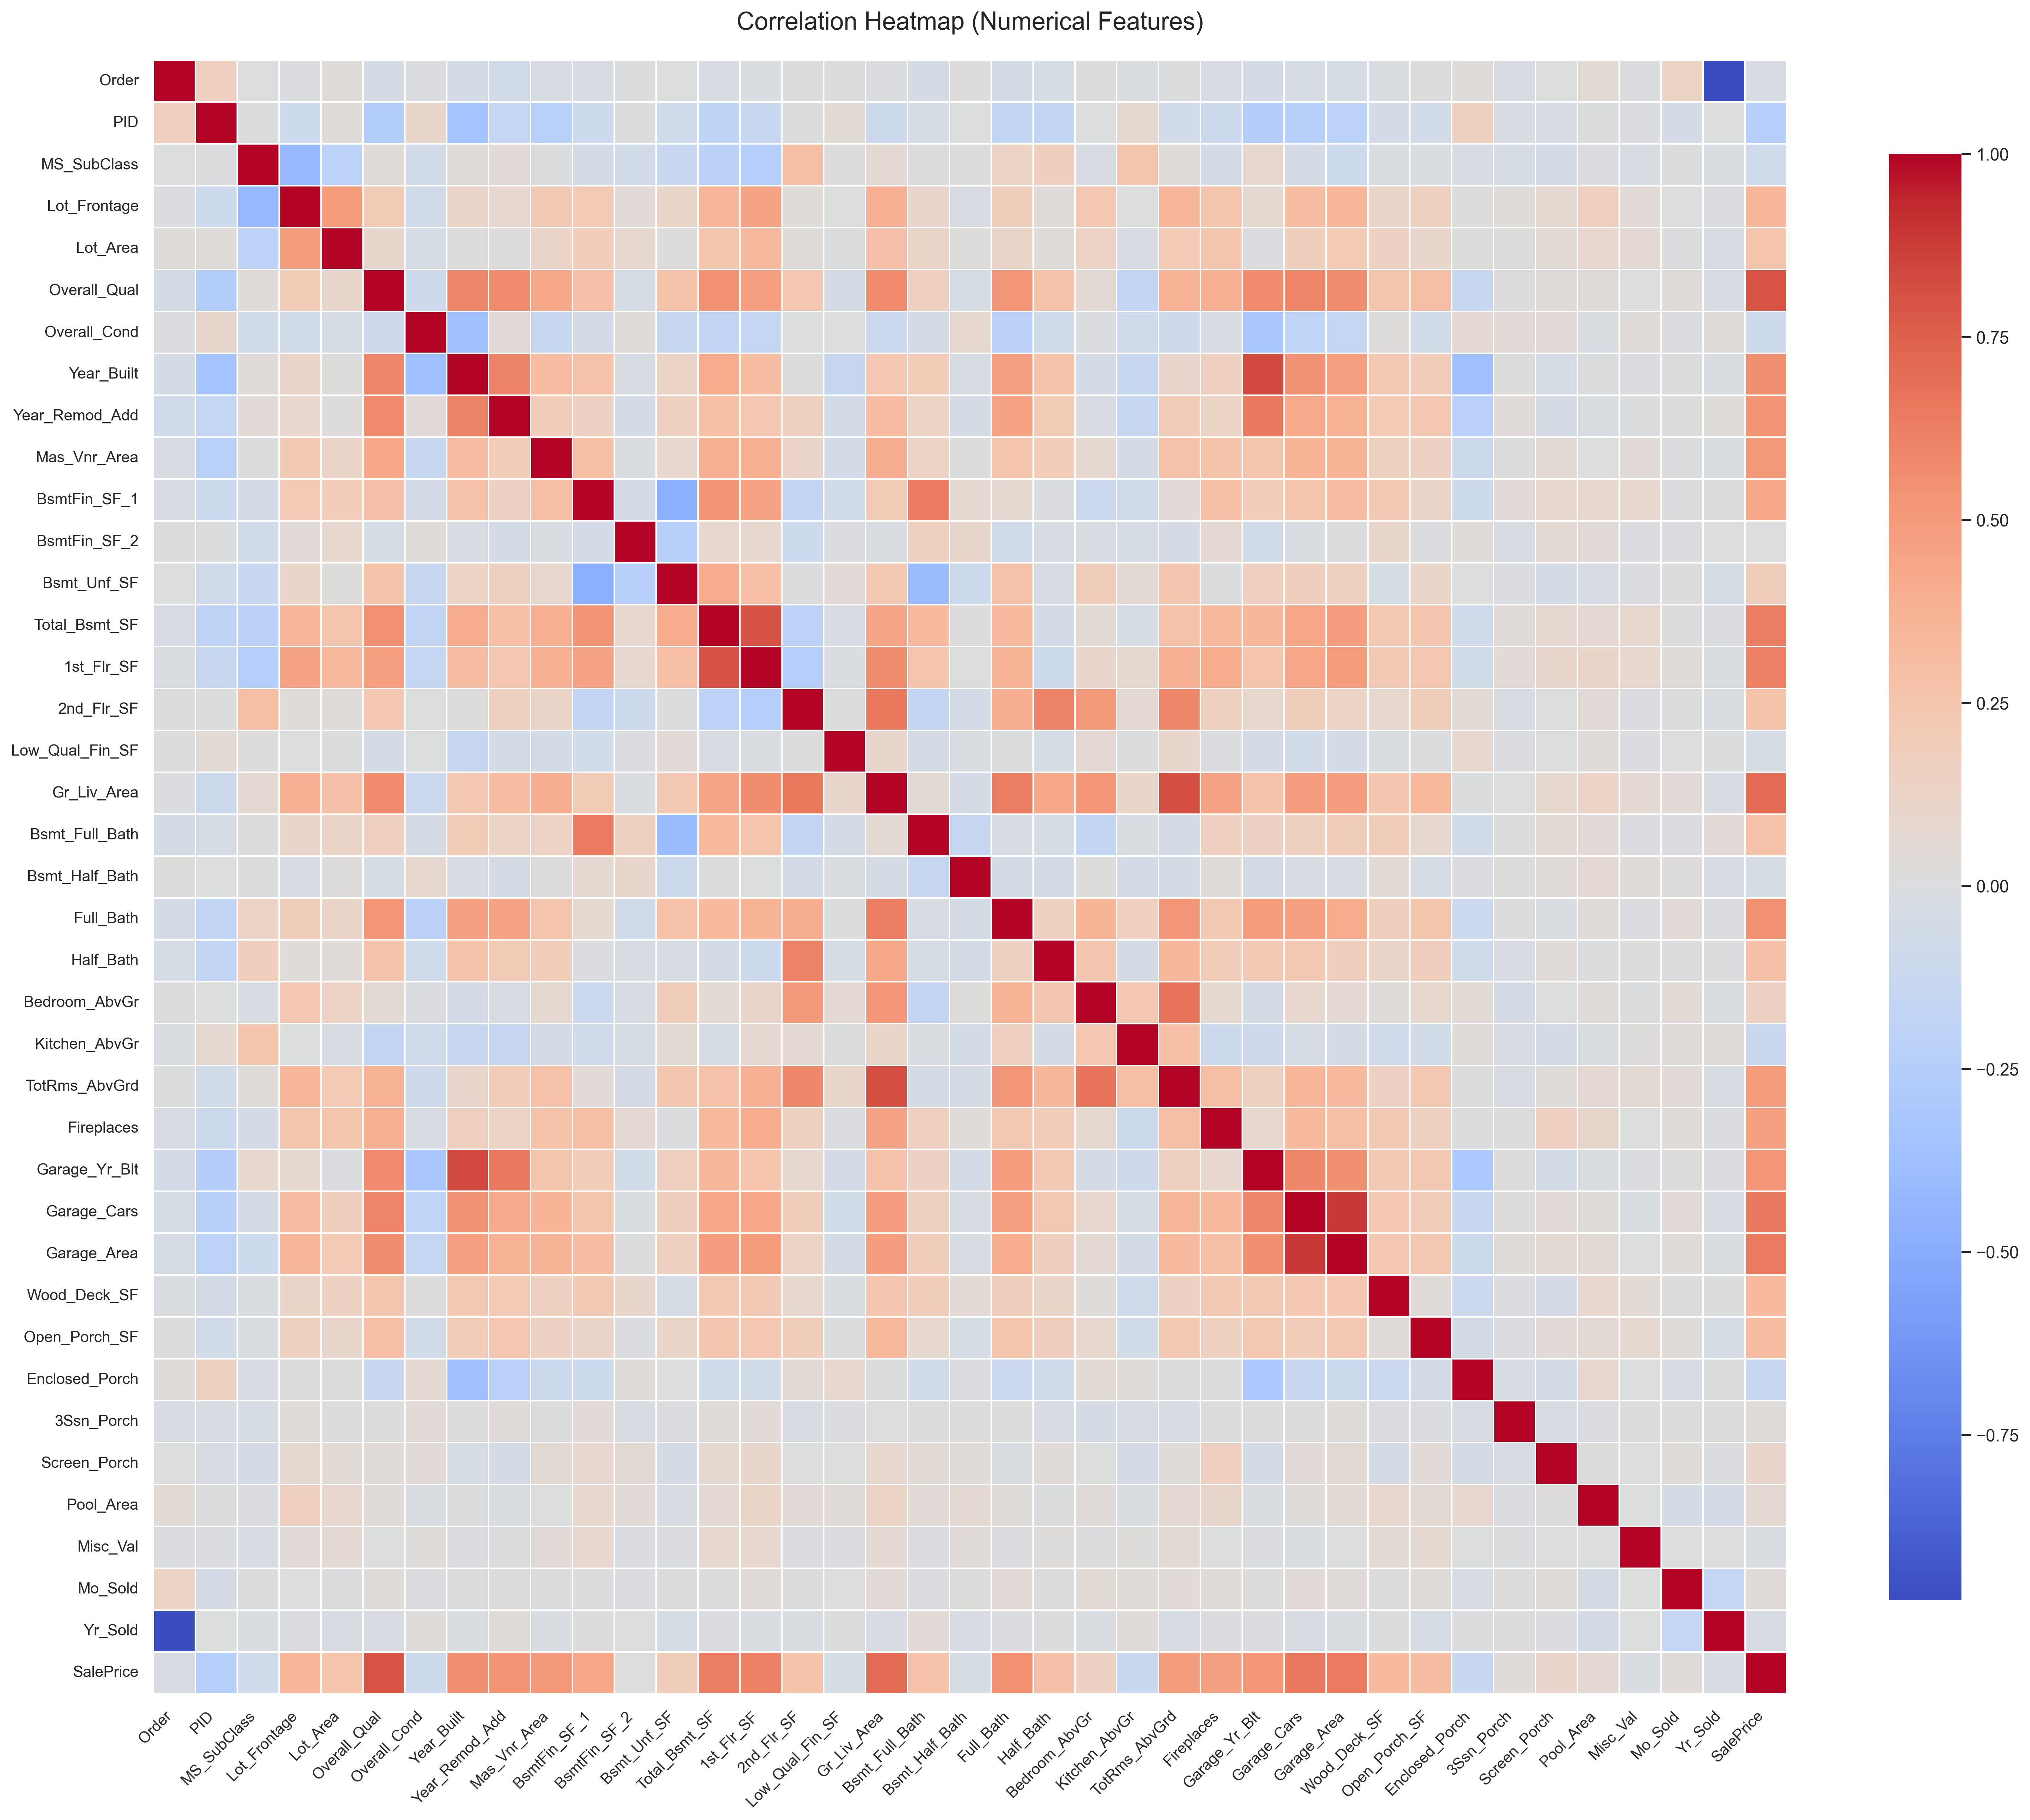

In [44]:
# Compute the correlation matrix for numeric features only
corr_matrix = df.corr(numeric_only=True)

# Set up the figure with higher DPI for better clarity
plt.figure(figsize=(20, 18), dpi=300)  # DPI increased from default (72) to 150 for sharpness

# Create the heatmap
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',      # Red-blue color gradient
    annot=False,          # Set to True if you want to display the correlation coefficients
    linewidths=0.5,
    fmt='.2f',            # Format for annotation numbers
    square=True,          # Makes each cell square-shaped
    cbar_kws={'shrink': 0.75}  # Shrinks the colorbar for better layout
)

# Plot the heatmap
plt.title('Correlation Heatmap (Numerical Features)', fontsize=16, pad=20)
plt.xticks(fontsize=10, rotation=45, ha='right') 
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

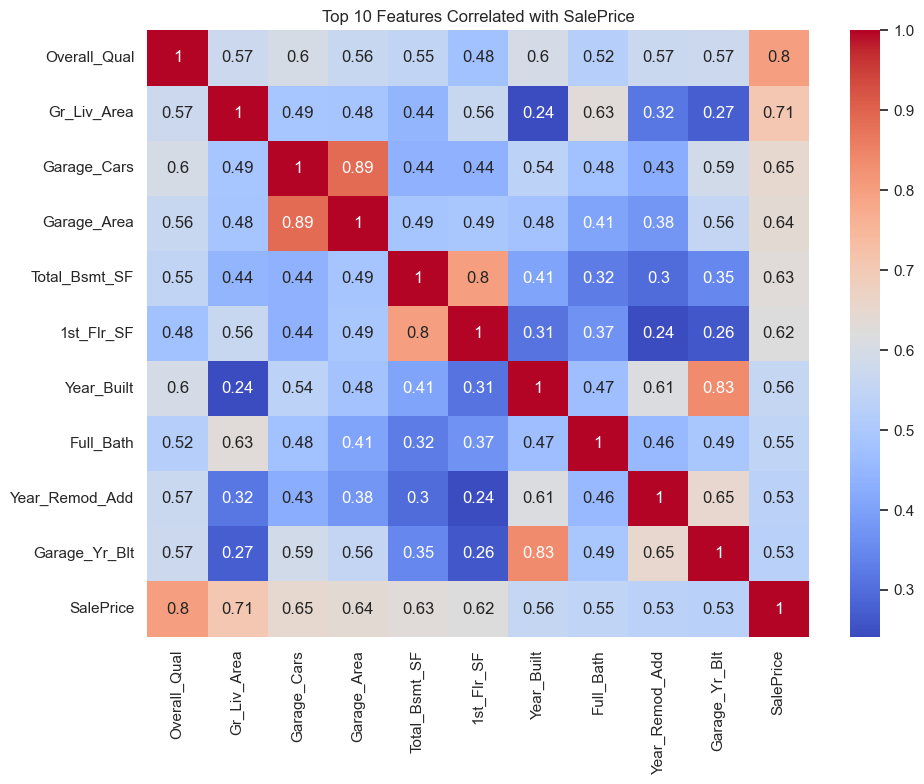

In [45]:
target = 'SalePrice'
top_n = 10
top_features = corr_matrix[target].abs().sort_values(ascending=False).iloc[1:top_n+1].index
top_corr_matrix = df[top_features.tolist() + [target]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm')
plt.title(f'Top {top_n} Features Correlated with {target}')
plt.tight_layout()
plt.show()

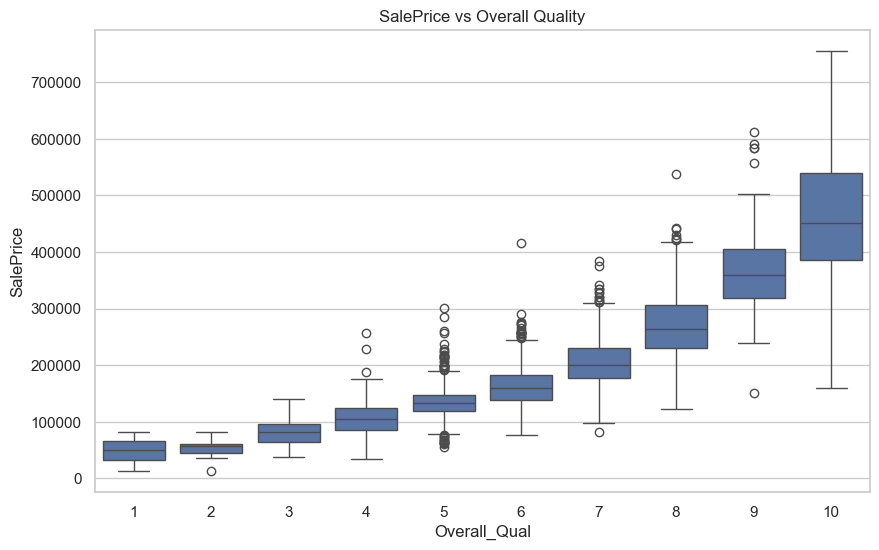

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Overall_Qual', y='SalePrice', data=df)
plt.title('SalePrice vs Overall Quality')
plt.show()

In [47]:
# Drop NA and get numeric cols
df_numeric = df.select_dtypes(include=np.number).dropna()
X = df_numeric.drop('SalePrice', axis=1, errors='ignore')
X_scaled = StandardScaler().fit_transform(X)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif.sort_values('VIF', ascending=False).head(10)

,Feature,VIF
10,BsmtFin_SF_1,inf
17,Gr_Liv_Area,inf
16,Low_Qual_Fin_SF,inf
15,2nd_Flr_SF,inf
14,1st_Flr_SF,inf
13,Total_Bsmt_SF,inf
12,Bsmt_Unf_SF,inf
11,BsmtFin_SF_2,inf
0,Order,80.916598
37,Yr_Sold,78.382693


## Numerical Feature Analysis
This section analyzes the numerical features in the dataset, focusing on their distributions, relationships with the target (`SalePrice`), and potential transformations for skewed variables.

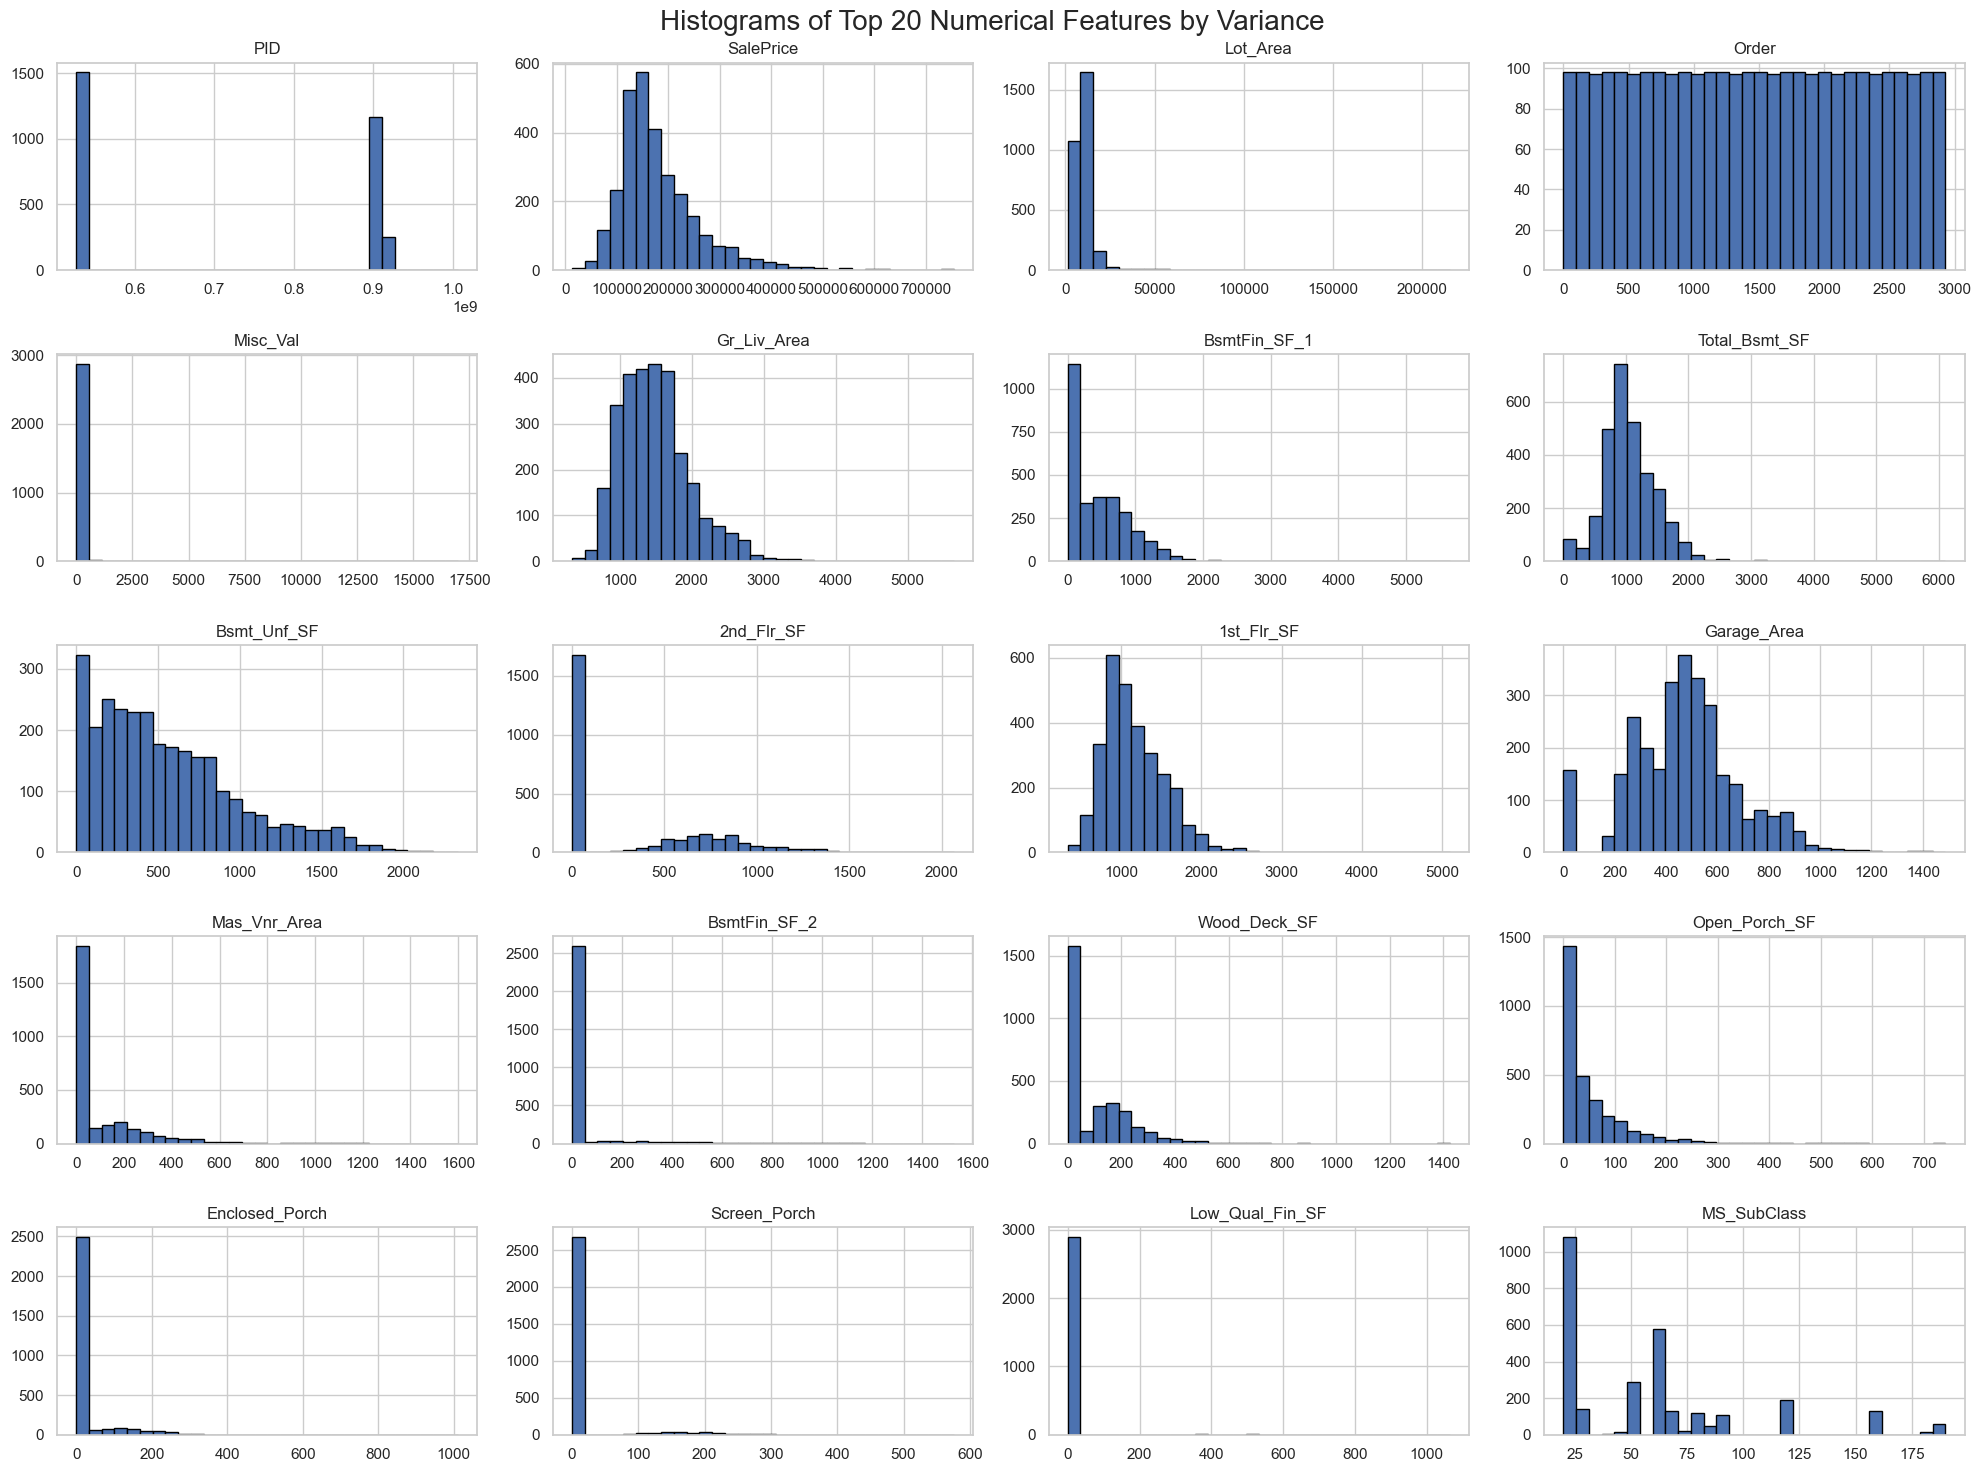

In [48]:
# Histogram Distribution of Numerical Features
# Histograms of Top 20 Numerical Features by Variance
top_numeric_by_var = (
    df.select_dtypes(include=np.number)
    .var()
    .sort_values(ascending=False)
    .head(20)
    .index
)

# Plot histograms only for these 20 features
df[top_numeric_by_var].hist(
    figsize=(20, 15), 
    bins=30, 
    edgecolor='black'
)

plt.suptitle("Histograms of Top 20 Numerical Features by Variance", fontsize=20)
plt.tight_layout()
plt.show()

In [49]:
# Toggle for Optional Full Plots
# Set show_all = True to display full histograms and bar plots of numerical features
show_all_numerical = False

In [50]:
# Optional: All Numerical Feature Histograms
if show_all_numerical:
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols].hist(figsize=(20, 15), bins=30, edgecolor='black')
    plt.suptitle("Histograms of All Numerical Features", fontsize=20)
    plt.tight_layout()
    plt.show()

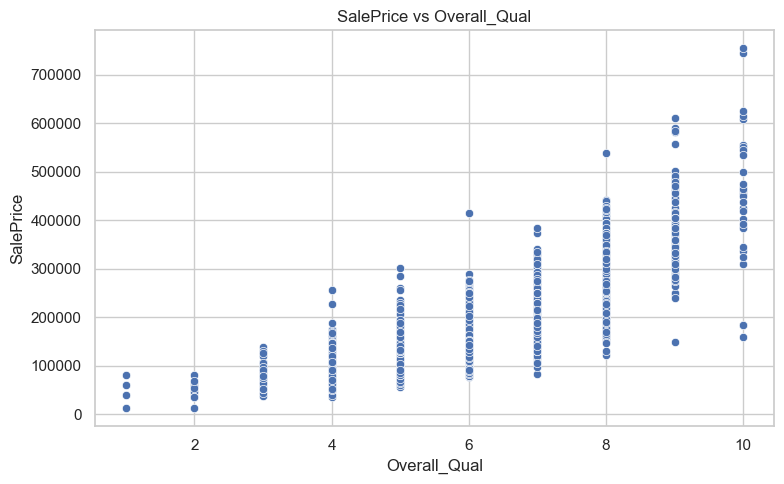

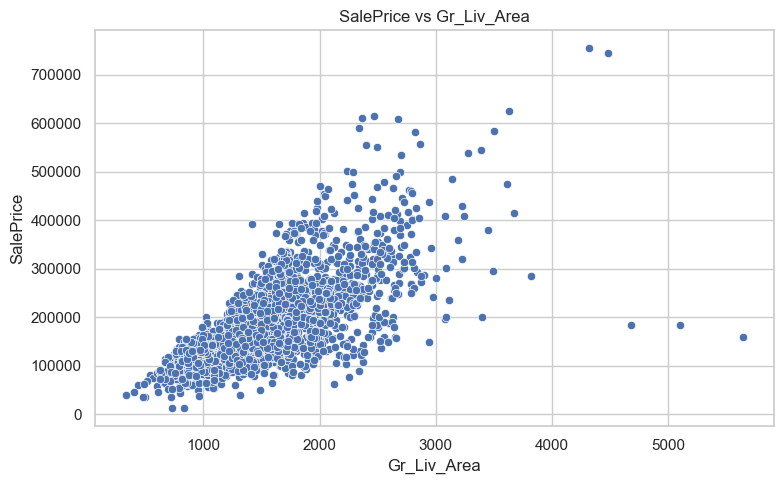

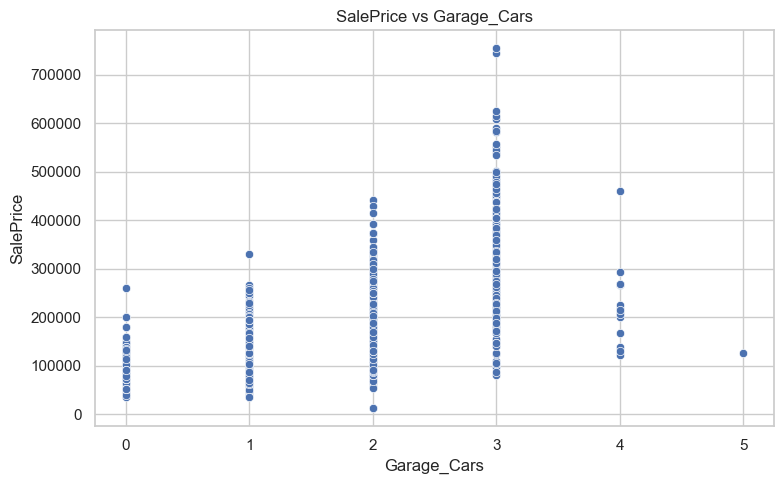

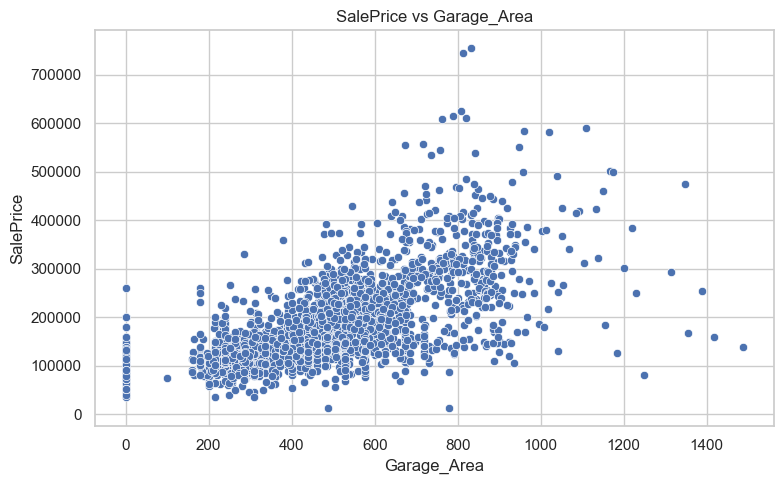

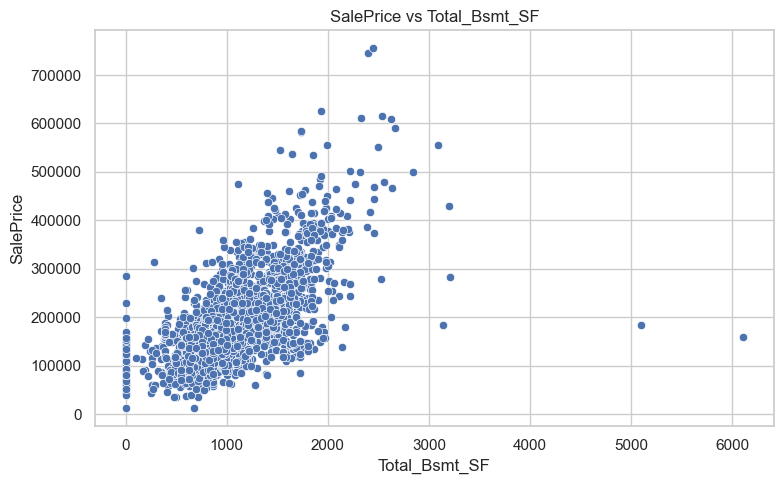

In [51]:
# Scatterplots for Top Features Correlated with SalePrice
# This helps us understand linear or nonlinear trends between numeric features and the target.
top_features = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)[1:6].index

for col in top_features:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=col, y='SalePrice', data=df)
    plt.title(f'SalePrice vs {col}')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.tight_layout()
    plt.show()

In [52]:
# Skewness of Numerical Features
# This identifies features with heavy skew (|skew| > 1), which may benefit from log transformation.
numeric_cols = df.select_dtypes(include=np.number).columns
skewed_feats = df[numeric_cols].skew().sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 1]
high_skew.to_frame('Skewness')

,Skewness
Misc_Val,21.999788
Pool_Area,16.939142
Lot_Area,12.820898
Low_Qual_Fin_SF,12.118162
3Ssn_Porch,11.403795
Kitchen_AbvGr,4.313825
BsmtFin_SF_2,4.139978
Enclosed_Porch,4.014446
Screen_Porch,3.957467
Bsmt_Half_Bath,3.940795


## Categorical Feature Analysis
This section explores the distribution of categorical features and their relationships with the target (`SalePrice`).

- We show barplots for the **top 20 most diverse** (high cardinality) features.
- An optional toggle is available to show **all categorical feature barplots**.
- We also explore boxplots for **ordinal** and **top nominal** features in relation to `SalePrice`.

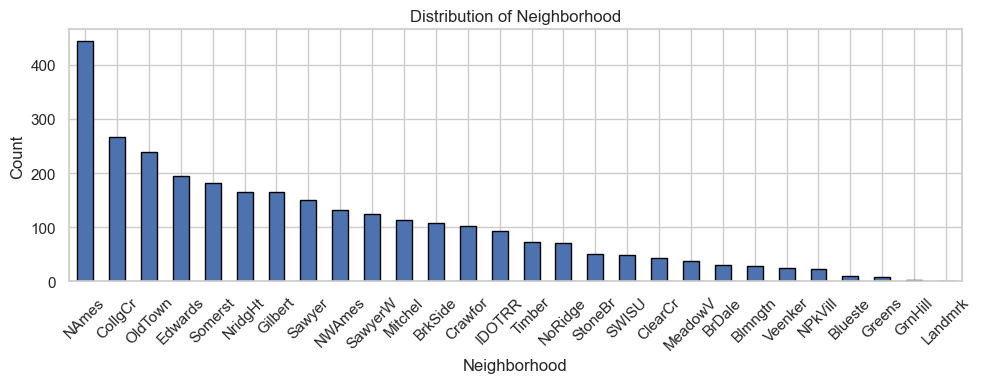

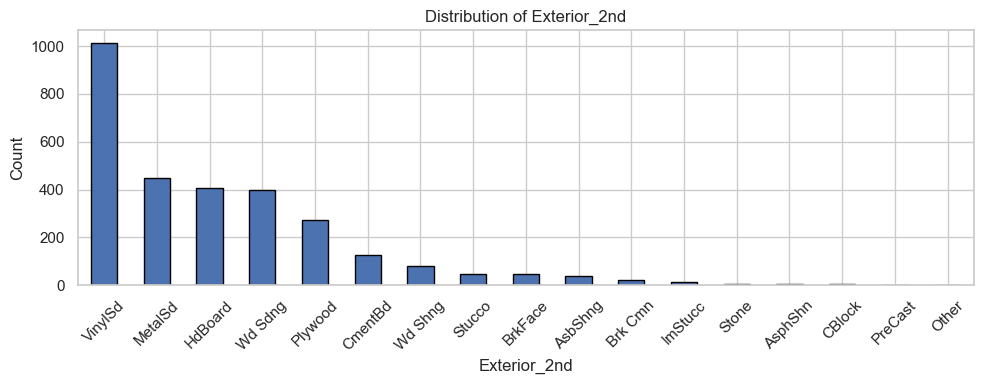

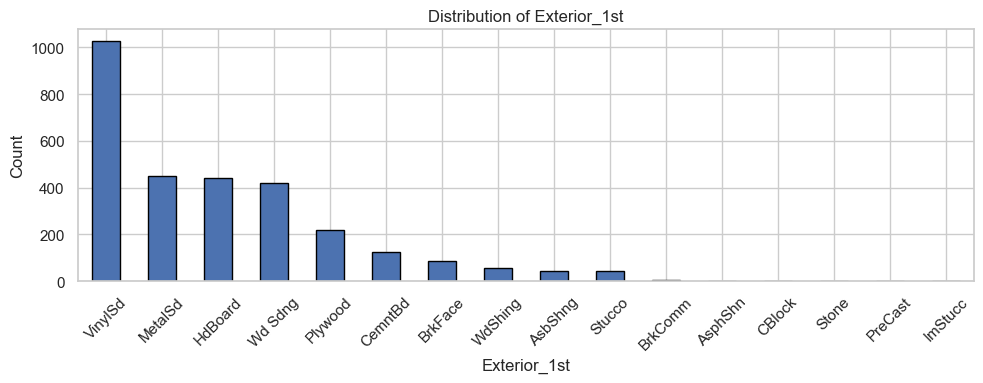

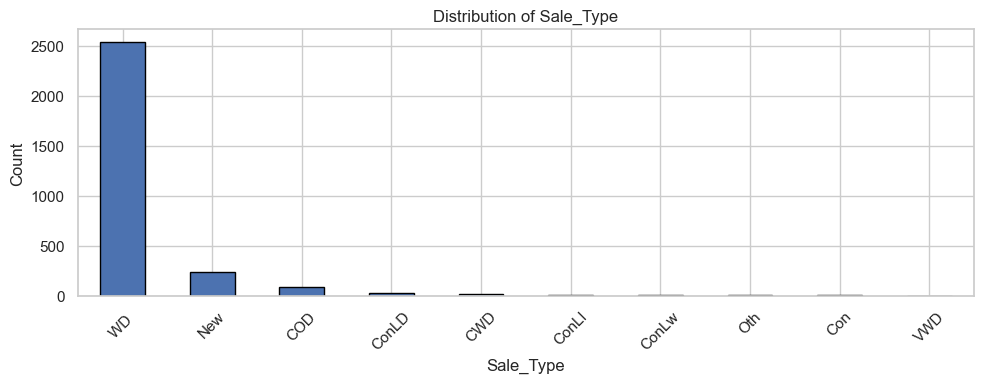

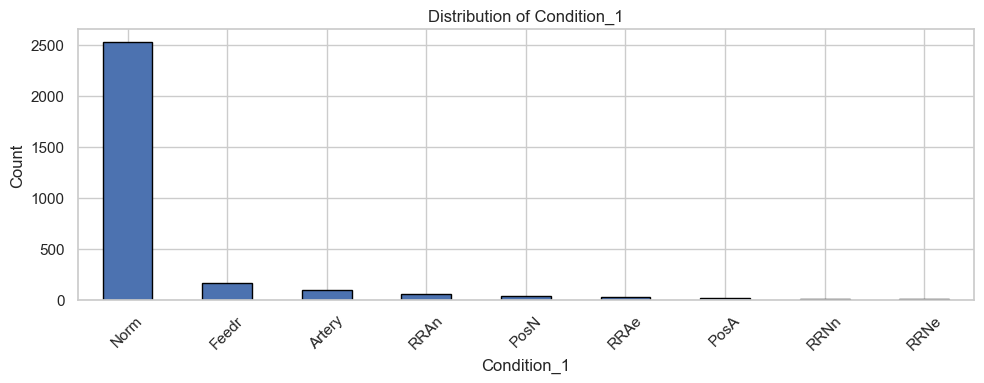

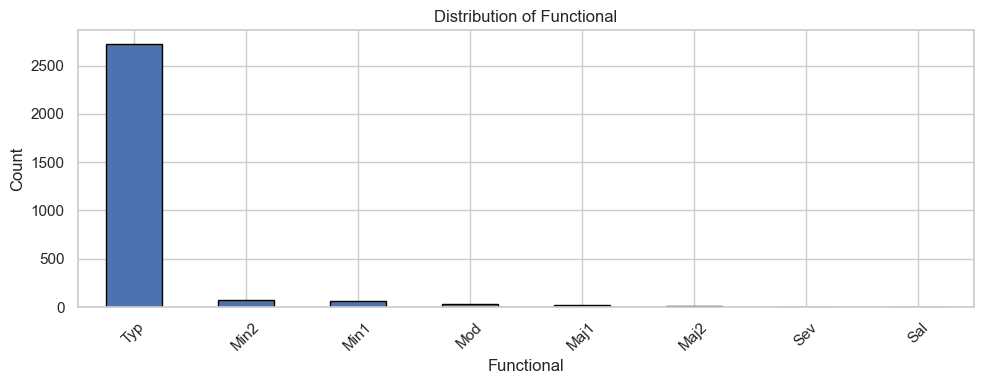

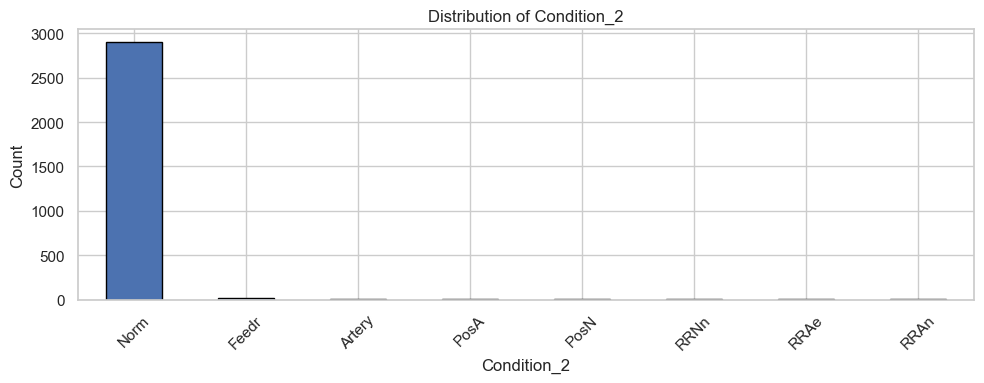

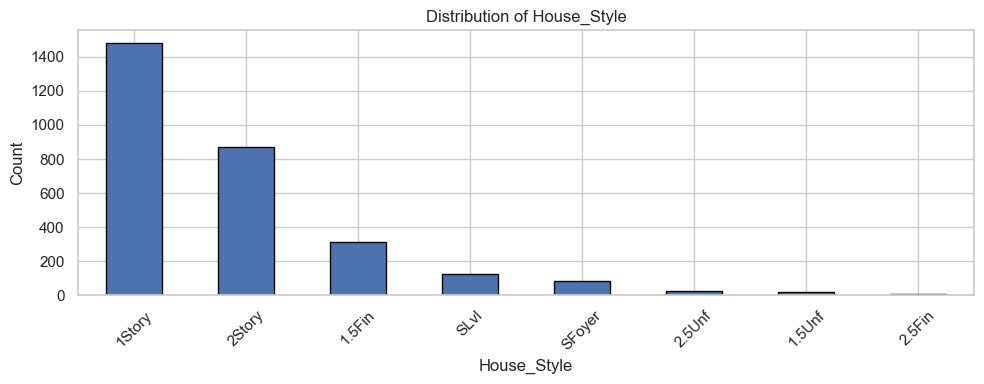

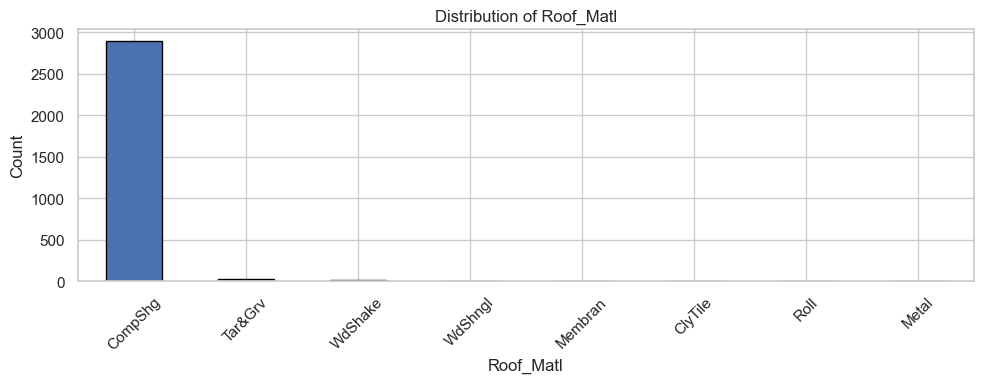

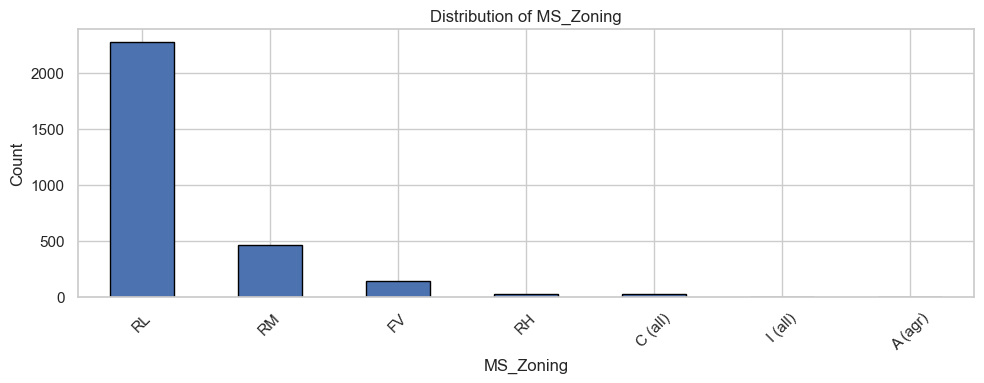

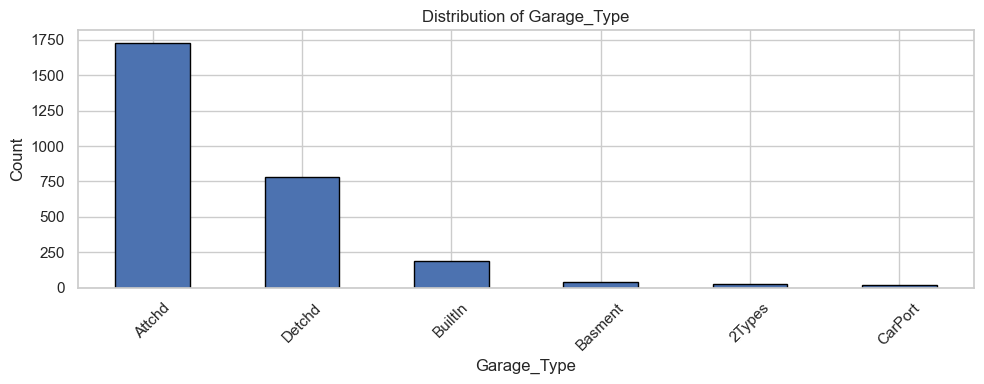

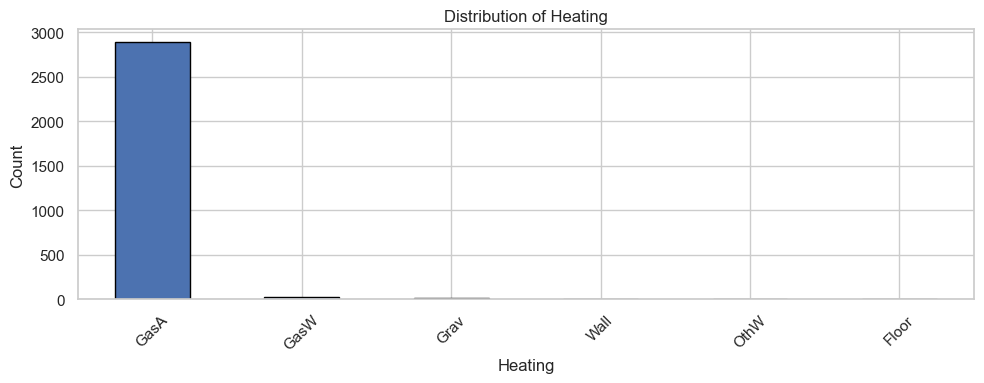

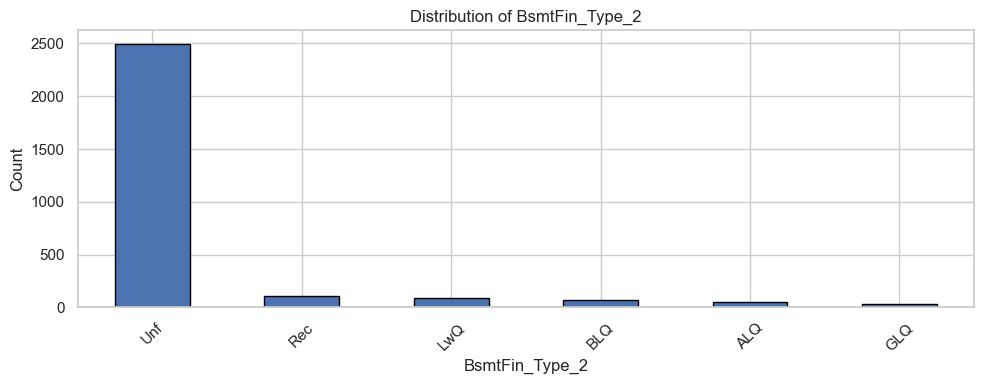

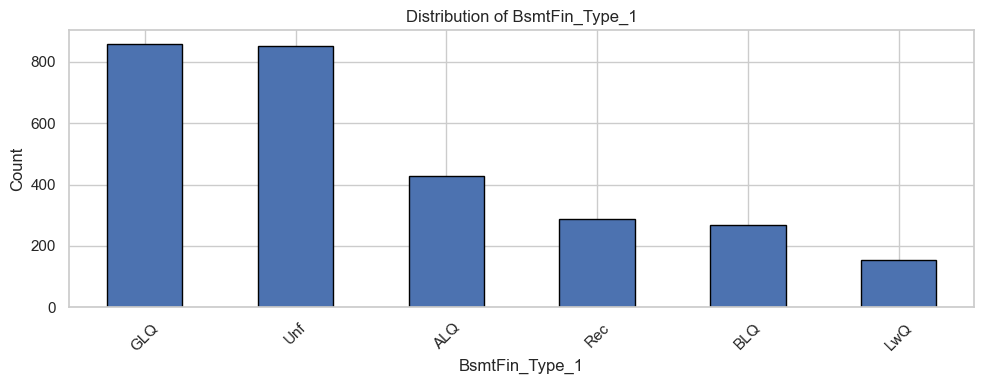

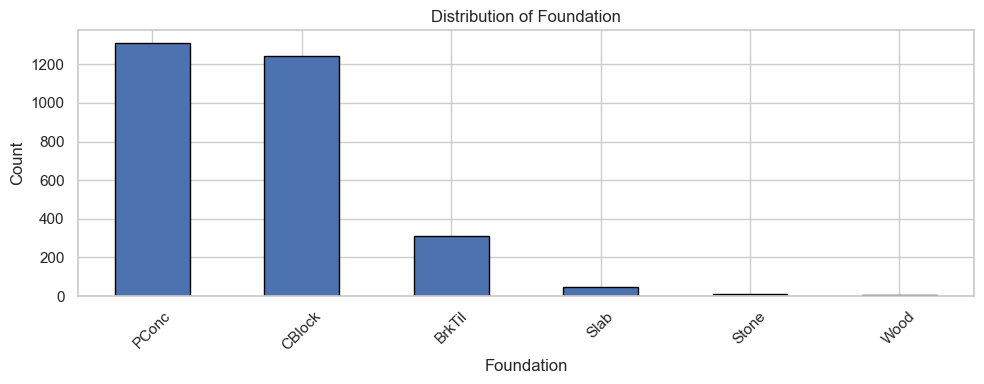

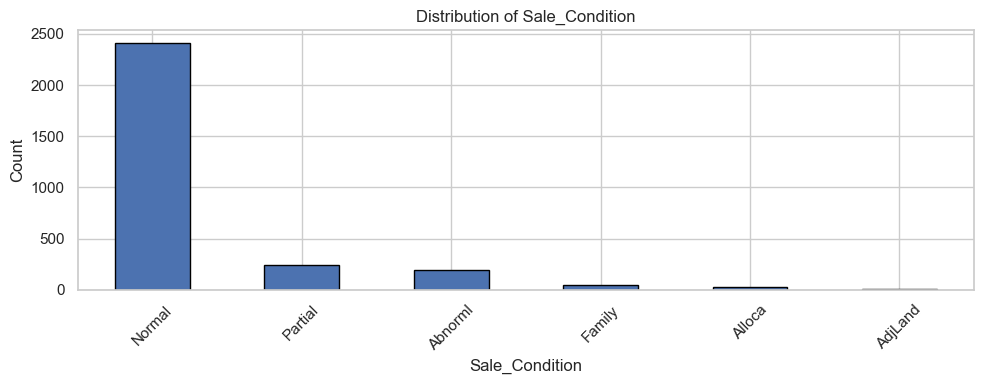

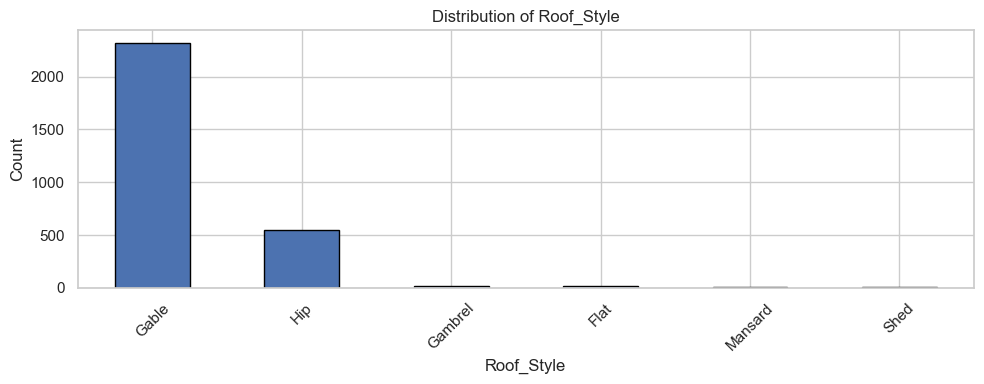

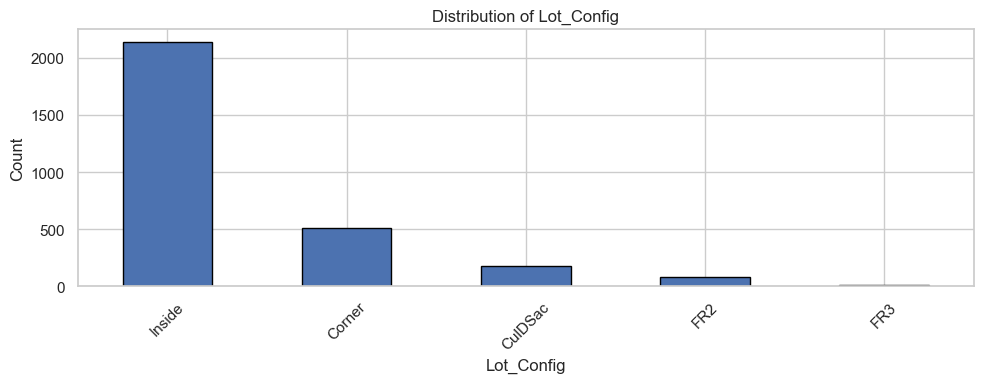

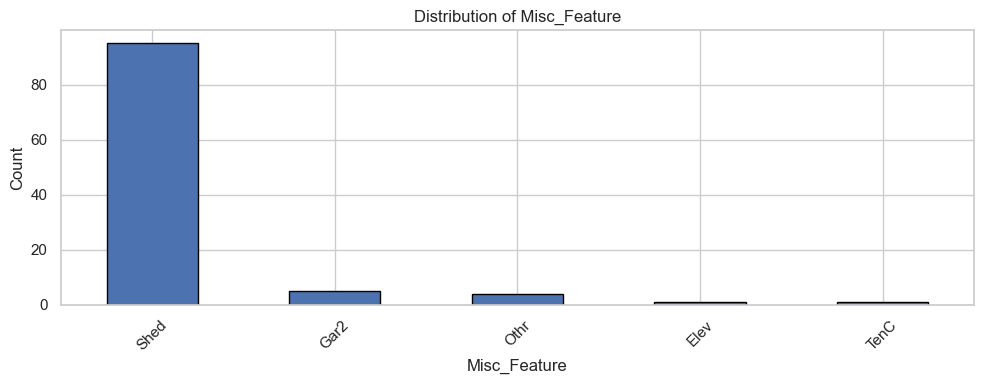

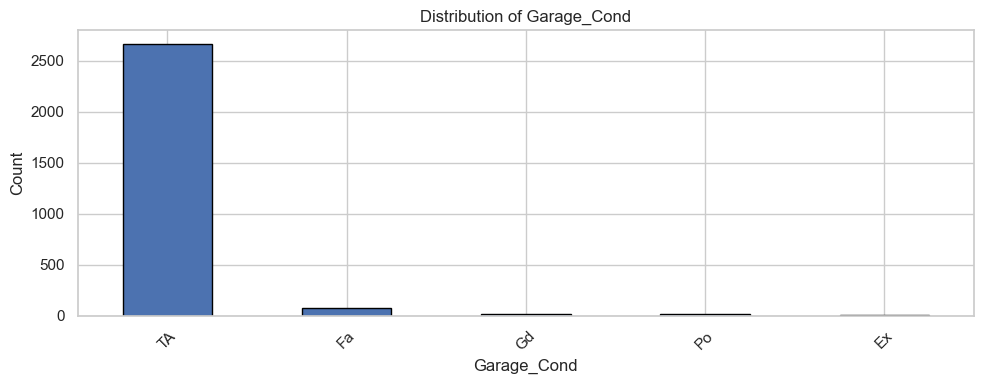

In [53]:
# Frequency Plots for Top 20 Categorical Features by Cardinality
cat_cols = df.select_dtypes(include='object').columns
top_20_cat = df[cat_cols].nunique().sort_values(ascending=False).head(20).index

for col in top_20_cat:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind='bar', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [54]:
# Toggle for Optional Full Plots
# Set show_all = True to display full histograms and bar plots of categorical features
show_all_categorical = False

In [55]:
# Optional: All Categorical Feature Bar Plots
if show_all_categorical:
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        plt.figure(figsize=(10, 4))
        df[col].value_counts().plot(kind='bar', edgecolor='black')
        plt.title(f'Distribution of {col}')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

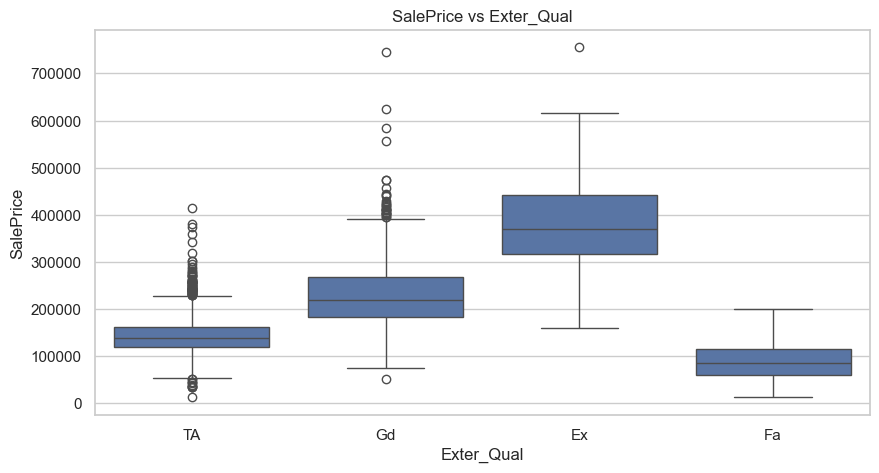

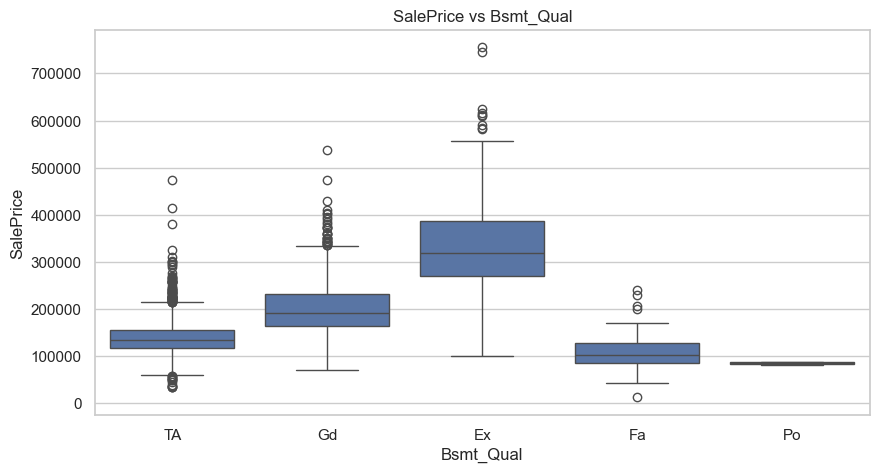

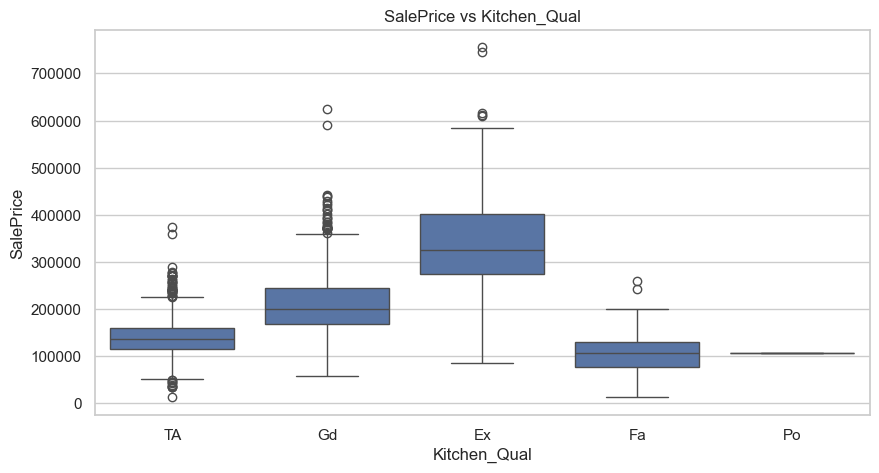

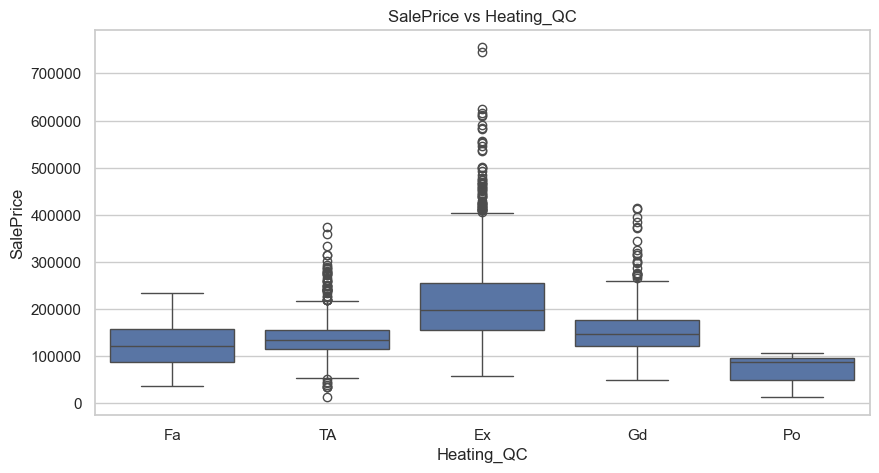

In [56]:
# Ordinal Features: SalePrice vs Ordinal Categories
ordinal_features = ['Exter_Qual', 'Bsmt_Qual', 'Kitchen_Qual', 'Heating_QC']

for col in ordinal_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='SalePrice', data=df)
    plt.title(f'SalePrice vs {col}')
    plt.show()

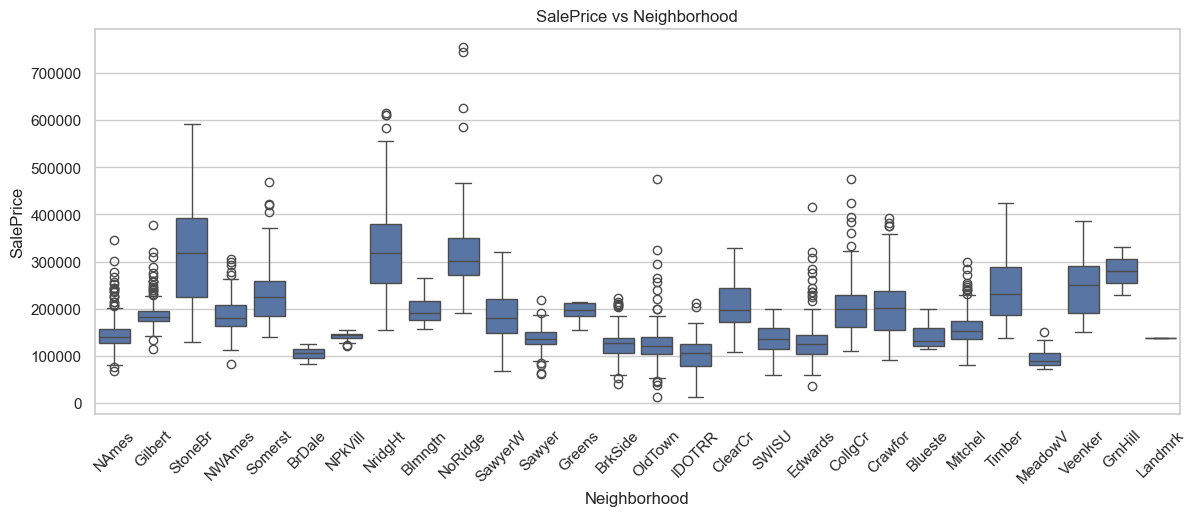

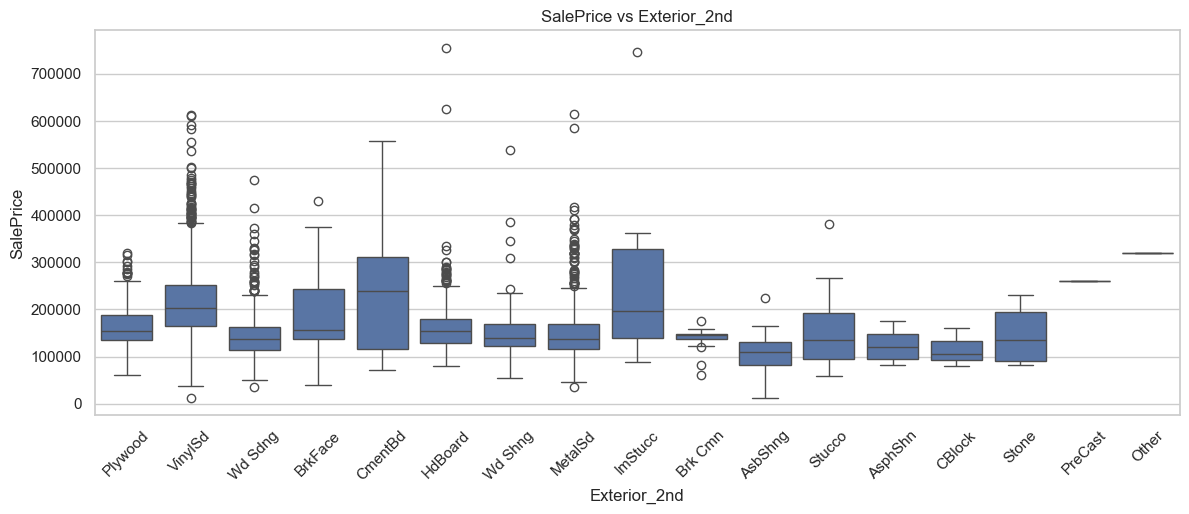

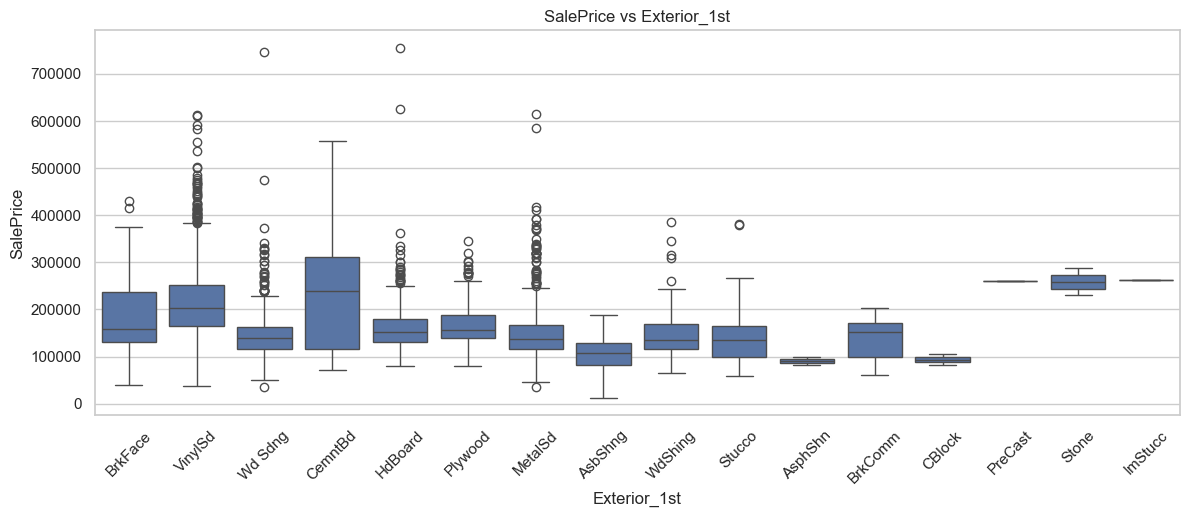

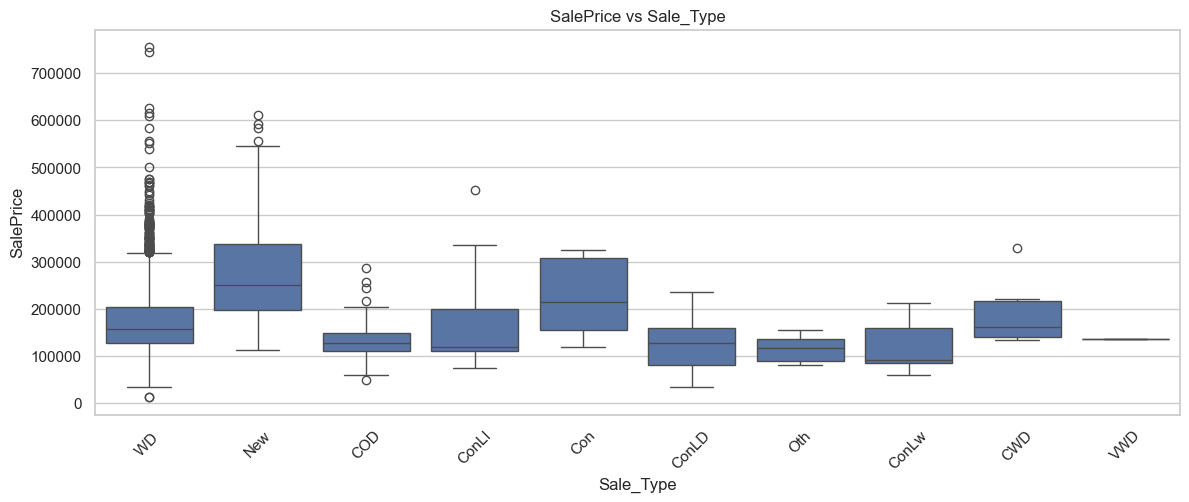

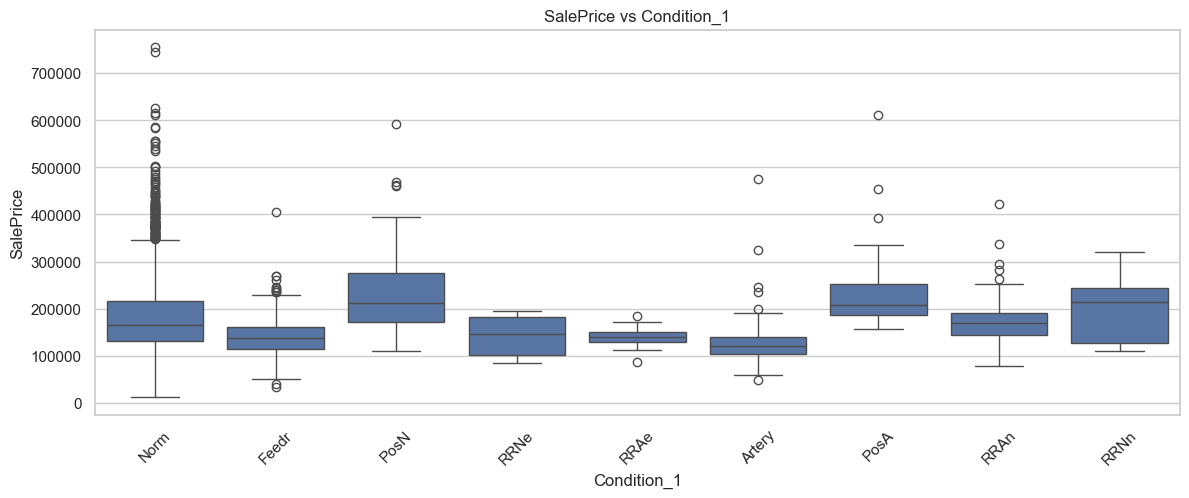

In [57]:
# Nominal Features: Top 5 by Unique Values
top_nominals = df.select_dtypes(include='object').nunique().sort_values(ascending=False).head(5).index

for col in top_nominals:
    plt.figure(figsize=(14, 5))
    sns.boxplot(x=col, y='SalePrice', data=df)
    plt.xticks(rotation=45)
    plt.title(f'SalePrice vs {col}')
    plt.show()

In [58]:
# Create an empty dictionary to hold ordinal feature mappings
ordinal_map = {}

# Get all object (categorical) features
cat_features = df.select_dtypes(include='object').columns

# Loop through each categorical feature
for feature in cat_features:
    unique_vals = df[feature].dropna().unique()
    
    # Only include features with a moderate number of unique values
    if 3 <= len(unique_vals) <= 10:
        try:
            ordered = (
                df.groupby(feature)["SalePrice"]
                .median()
                .sort_values()
                .index
                .tolist()
            )
            ordinal_map[feature] = ordered
        except Exception as e:
            print(f"⚠️ Skipping {feature}: {e}")

# Preview the suggested ordinal categories
import pprint
pprint.pprint(ordinal_map)

# Preview the suggested ordinal categories
import pprint
pprint.pprint(ordinal_map)

{'Bldg_Type': ['2fmCon', 'Twnhs', 'Duplex', '1Fam', 'TwnhsE'],
 'BsmtFin_Type_1': ['Rec', 'LwQ', 'BLQ', 'ALQ', 'Unf', 'GLQ'],
 'BsmtFin_Type_2': ['BLQ', 'Rec', 'LwQ', 'ALQ', 'Unf', 'GLQ'],
 'Bsmt_Cond': ['Po', 'Fa', 'Ex', 'TA', 'Gd'],
 'Bsmt_Exposure': ['No', 'Mn', 'Av', 'Gd'],
 'Bsmt_Qual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 'Condition_1': ['Artery',
                 'Feedr',
                 'RRAe',
                 'RRNe',
                 'Norm',
                 'RRAn',
                 'PosA',
                 'PosN',
                 'RRNn'],
 'Condition_2': ['RRNn',
                 'Artery',
                 'Feedr',
                 'RRAn',
                 'Norm',
                 'RRAe',
                 'PosN',
                 'PosA'],
 'Electrical': ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
 'Exter_Cond': ['Po', 'Fa', 'Gd', 'TA', 'Ex'],
 'Exter_Qual': ['Fa', 'TA', 'Gd', 'Ex'],
 'Fence': ['MnWw', 'MnPrv', 'GdWo', 'GdPrv'],
 'Fireplace_Qu': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],

## ✅ Summary

- We identified strong correlations, skewed features, and categorical variables influencing `SalePrice`.
- Missing data and outliers will be treated in preprocessing.
- Final features will be selected using Lasso or other techniques.